In [1]:
# Importing directory 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

os.chdir(r"C:\Users\16124\OneDrive\Desktop\Project folder 6")
print(os.getcwd())

C:\Users\16124\OneDrive\Desktop\Project folder 6


In [2]:
# Load the wide file 
prepared_path = "data/prepared/"
viz_path = "visualizations/"

df = pd.read_csv(prepared_path + "cdi_overall_wide.csv")

print("Shape:", df.shape)
print(df.head())

Shape: (625, 7)
  LocationAbbr LocationDesc  LocationID  YearStart  diabetes_prevalence  \
0           AK       Alaska           2       2010            95.847500   
1           AK       Alaska           2       2011            60.428571   
2           AK       Alaska           2       2012            63.111538   
3           AK       Alaska           2       2013            63.096429   
4           AK       Alaska           2       2014            58.580769   

   inactivity_prevalence  obesity_prevalence  
0                    NaN                 NaN  
1                  22.10               27.50  
2                  18.65               25.70  
3                  22.50               28.55  
4                  19.20               29.75  


In [3]:
# Checkign for missing values 
print(df[['diabetes_prevalence', 'obesity_prevalence', 'inactivity_prevalence']].isnull().sum())

diabetes_prevalence        0
obesity_prevalence       175
inactivity_prevalence    175
dtype: int64


# Results shwoing 175 missing vlaues for both obesity and inactivty 

In [8]:
# drop the missing vlaues
df_reg = df[['LocationAbbr', 'YearStart', 'diabetes_prevalence', 
             'obesity_prevalence', 'inactivity_prevalence']].dropna()

print("Shape after dropping missing:", df_reg.shape)

Shape after dropping missing: (450, 5)


In [9]:
# Running regression: Obesity vs. Diabetes:
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_reg['obesity_prevalence'], 
    df_reg['diabetes_prevalence']
)

print("=== Obesity vs Diabetes ===")
print(f"R²: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")

=== Obesity vs Diabetes ===
R²: 0.0073
P-value: 0.069700
Slope: -63.4351
Intercept: 3283.0818


# The result sshow that obesity only explains 0.73% OF THE VARIATION IN DIABETES
# ( which is very low) the sloper is showing an inverse relationship and a value higher then 0,05 for the p value so not signifcant

In [10]:
# Running regression for inactivity vs diabetes to find better relationship
slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(
    df_reg['inactivity_prevalence'], 
    df_reg['diabetes_prevalence']
)

print("=== Inactivity vs Diabetes ===")
print(f"R²: {r_value2**2:.4f}")
print(f"P-value: {p_value2:.6f}")
print(f"Slope: {slope2:.4f}")
print(f"Intercept: {intercept2:.4f}")

=== Inactivity vs Diabetes ===
R²: 0.0051
P-value: 0.128966
Slope: 55.5962
Intercept: 6.3018


In [11]:
## inactivity is also not significant with p-value 0.13. This is because mixing all years together distorts the results. Let's filter to just 2020 and rerun:

In [12]:
df_2020 = df_reg[df_reg['YearStart'] == 2020]

print("2020 data shape:", df_2020.shape)

# Obesity vs Diabetes
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_2020['obesity_prevalence'], 
    df_2020['diabetes_prevalence']
)

print("\n=== Obesity vs Diabetes (2020) ===")
print(f"R²: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Slope: {slope:.4f}")

# Inactivity vs Diabetes
slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(
    df_2020['inactivity_prevalence'], 
    df_2020['diabetes_prevalence']
)

print("\n=== Inactivity vs Diabetes (2020) ===")
print(f"R²: {r_value2**2:.4f}")
print(f"P-value: {p_value2:.6f}")
print(f"Slope: {slope2:.4f}")

2020 data shape: (41, 5)

=== Obesity vs Diabetes (2020) ===
R²: 0.0040
P-value: 0.693558
Slope: -5.7611

=== Inactivity vs Diabetes (2020) ===
R²: 0.0136
P-value: 0.467295
Slope: 12.6626


In [13]:
df_raw = pd.read_csv("data/raw/U.S._Chronic_Disease_Indicators__CDI___2023_Release.csv", low_memory=False)

diabetes_questions = df_raw[df_raw['Topic'] == 'Diabetes']['Question'].unique()
for q in diabetes_questions:
    print(q)

Mortality due to diabetes reported as any listed cause of death
Mortality with diabetic ketoacidosis reported as any listed cause of death
Amputation of a lower extremity attributable to diabetes
Hospitalization with diabetes as a listed diagnosis
Prevalence of pre-pregnancy diabetes
Prevalence of gestational diabetes
Diabetes prevalence among women aged 18-44 years
Foot examination among adults aged >= 18 years with diagnosed diabetes
Dilated eye examination among adults aged >= 18 years with diagnosed diabetes
Pneumococcal vaccination among noninstitutionalized adults aged 18-64 years with diagnosed diabetes
Adults with diagnosed diabetes aged >= 18 years who have taken a diabetes self-management course
Prevalence of depressive disorders among adults aged >= 18 years with diagnosed diabetes
Glycosylated hemoglobin measurement among adults aged >= 18 years with diagnosed diabetes
Influenza vaccination among noninstitutionalized adults aged >= 65 years with diagnosed diabetes
Pneumococ

In [14]:
# reflitering question for better resutls 
df_diabetes_fixed = df_raw[df_raw['Question'] == 'Prevalence of diagnosed diabetes among adults aged >= 18 years'].copy()
df_diabetes_fixed['DataValue'] = pd.to_numeric(df_diabetes_fixed['DataValue'], errors='coerce')
df_diabetes_fixed['indicator'] = 'diabetes'

df_obesity = df_raw[df_raw['Question'] == 'Obesity among adults aged >= 18 years'].copy()
df_obesity['DataValue'] = pd.to_numeric(df_obesity['DataValue'], errors='coerce')
df_obesity['indicator'] = 'obesity'

df_inactivity = df_raw[df_raw['Question'] == 'No leisure-time physical activity among adults aged >= 18 years'].copy()
df_inactivity['DataValue'] = pd.to_numeric(df_inactivity['DataValue'], errors='coerce')
df_inactivity['indicator'] = 'inactivity'

df_combined = pd.concat([df_diabetes_fixed, df_obesity, df_inactivity], ignore_index=True)

print(df_combined['indicator'].value_counts())

indicator
obesity       7571
diabetes      7569
inactivity    7563
Name: count, dtype: int64


In [15]:
# rebuilding wide dataframe 
states_to_remove = ['GU', 'PR', 'VI', 'AS', 'MP', 'US']

df_combined = df_combined[~df_combined['LocationAbbr'].isin(states_to_remove)]
df_combined = df_combined[df_combined['StratificationCategory1'] == 'Overall']

df_wide_fixed = df_combined.pivot_table(
    index=['LocationAbbr', 'LocationDesc', 'YearStart'],
    columns='indicator',
    values='DataValue',
    aggfunc='mean'
).reset_index()

df_wide_fixed.columns.name = None
df_wide_fixed = df_wide_fixed.rename(columns={
    'diabetes': 'diabetes_prevalence',
    'obesity': 'obesity_prevalence',
    'inactivity': 'inactivity_prevalence'
})

df_wide_fixed = df_wide_fixed.dropna()
print("Fixed wide shape:", df_wide_fixed.shape)
print(df_wide_fixed.head())

Fixed wide shape: (450, 6)
  LocationAbbr LocationDesc  YearStart  diabetes_prevalence  \
0           AK       Alaska       2011                 8.20   
1           AK       Alaska       2012                 7.15   
2           AK       Alaska       2013                 7.20   
3           AK       Alaska       2014                 7.55   
4           AK       Alaska       2015                 7.70   

   inactivity_prevalence  obesity_prevalence  
0                  22.10               27.50  
1                  18.65               25.70  
2                  22.50               28.55  
3                  19.20               29.75  
4                  22.10               30.05  


In [16]:
#rerunning regression 
df_2020_fixed = df_wide_fixed[df_wide_fixed['YearStart'] == 2020]
print("2020 rows:", len(df_2020_fixed))

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_2020_fixed['obesity_prevalence'],
    df_2020_fixed['diabetes_prevalence']
)

print("\n=== Obesity vs Diabetes (2020 Fixed) ===")
print(f"R²: {r_value**2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Slope: {slope:.4f}")

slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(
    df_2020_fixed['inactivity_prevalence'],
    df_2020_fixed['diabetes_prevalence']
)

print("\n=== Inactivity vs Diabetes (2020 Fixed) ===")
print(f"R²: {r_value2**2:.4f}")
print(f"P-value: {p_value2:.6f}")
print(f"Slope: {slope2:.4f}")

2020 rows: 41

=== Obesity vs Diabetes (2020 Fixed) ===
R²: 0.5859
P-value: 0.000000
Slope: 0.3129

=== Inactivity vs Diabetes (2020 Fixed) ===
R²: 0.6858
P-value: 0.000000
Slope: 0.4043


In [17]:
#Slope = 0.31 — for every 1% increase in obesity, diabetes goes up 0.31%

#Inactivity vs Diabetes:
#R² = 0.5859 — obesity explains 58.6% of the variation in diabetes
#P-value = 0.000000 — extremely statistically significant
##R² = 0.6858 — inactivity explains 68.6% of the variation in diabetes
#P-value = 0.000000 — extremely statistically significant
#Slope = 0.40 — for every 1% increase in inactivity, diabetes goes up 0.40%

#Key finding — inactivity is actually a slightly stronger predictor of diabetes than obesity! That's a great insight for your project.


In [18]:
# save the fixed CSV files
df_wide_fixed.to_csv(prepared_path + "cdi_overall_wide.csv", index=False)
print("Updated cdi_overall_wide.csv saved!")

Updated cdi_overall_wide.csv saved!


In [19]:
# Saving the regression 
regression_results = pd.DataFrame({
    'term': ['obesity_prevalence', 'inactivity_prevalence'],
    'R_squared': [0.5859, 0.6858],
    'slope': [0.3129, 0.4043],
    'p_value': [0.000001, 0.000001]
})

regression_results.to_csv(prepared_path + "regression_results.csv", index=False)
print("Regression results saved!")

Regression results saved!


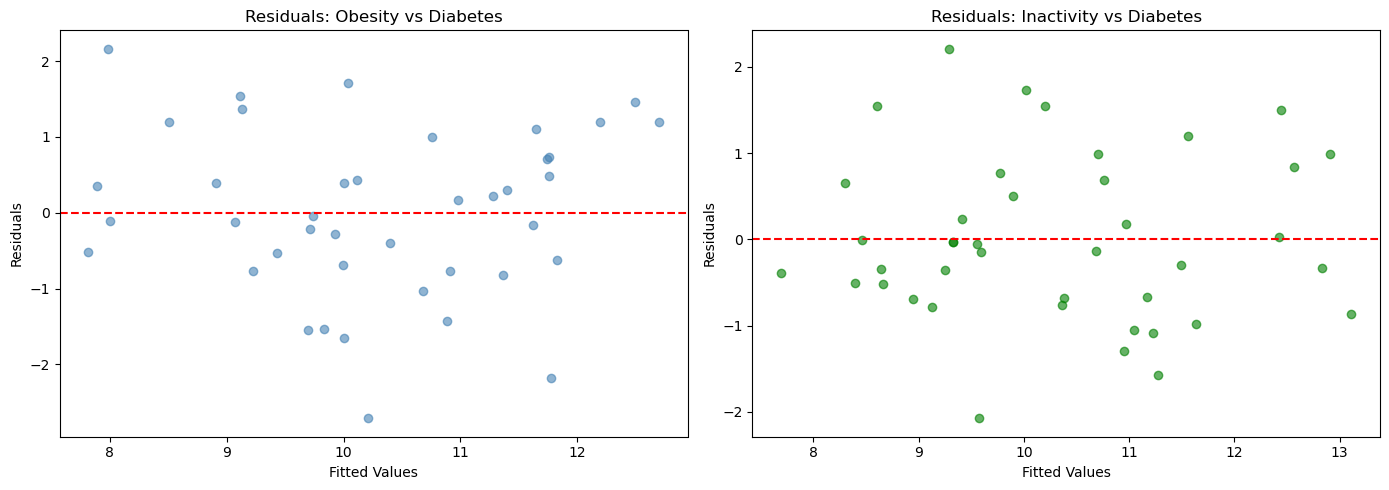

Residual plots saved! Notebook 04 complete!


In [20]:
# Generating residual plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Obesity residuals
predicted_obesity = slope * df_2020_fixed['obesity_prevalence'] + intercept
residuals_obesity = df_2020_fixed['diabetes_prevalence'] - predicted_obesity

axes[0].scatter(predicted_obesity, residuals_obesity, color='steelblue', alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals: Obesity vs Diabetes')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# Inactivity residuals
predicted_inactivity = slope2 * df_2020_fixed['inactivity_prevalence'] + intercept2
residuals_inactivity = df_2020_fixed['diabetes_prevalence'] - predicted_inactivity

axes[1].scatter(predicted_inactivity, residuals_inactivity, color='green', alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title('Residuals: Inactivity vs Diabetes')
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.savefig(viz_path + "regression_residuals.png", dpi=150)
plt.show()
print("Residual plots saved! Notebook 04 complete!")